<a href="https://colab.research.google.com/github/Wafik20/SOTA-deep-learning-code-samples/blob/main/Neural_ODEs_Unlocked.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torchdiffeq

In [2]:
import torch
import torch.nn as nn
from torchdiffeq import odeint
# Define a simple decoder that takes a datum (a 2d point in our case of the half-moons dataset) and projects it in R^n = hidden_dim
class ODEFunc(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, t, h):
        # All we need for the forward is computing f_1(h), starting from f_0(h)
        return self.net(h)

In [3]:
class ODEBlock(nn.Module):
    def __init__(self, odefunc, t0=0.0, t1=1.0):
        super().__init__()
        self.odefunc = odefunc
        self.integration_time = torch.tensor([t0, t1], dtype=torch.float32) # WHAT DOES THIS DO?

    def forward(self, h0):
        t = self.integration_time.to(h0.device)
        out = odeint(self.odefunc, h0, t, method="dopri5") # this does backprop by solving the ode
        # out shape: [num_times, batch, hidden_dim]
        return out[-1]

In [4]:
class NeuralODEClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )

        self.odeblock = ODEBlock(ODEFunc(hidden_dim))

        self.head = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        h = self.encoder(x)
        h = self.odeblock(h)
        logits = self.head(h)
        return logits

In [5]:
def train_step(model, x, y, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    logits = model(x)
    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

    return loss.item()

In [15]:
from sklearn.datasets import make_moons

X, Y = make_moons(n_samples=512, noise=0.4)

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

x_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

x_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

In [16]:
batch_size = 32
input_dim = 2
hidden_dim = 64
num_classes = 2

model = NeuralODEClassifier(input_dim, hidden_dim, num_classes)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

In [17]:
for step in range(300):

    idx = torch.randint(0, len(x_train), (batch_size,))
    xb = x_train[idx]
    yb = y_train[idx]

    optimizer.zero_grad()

    logits = model(xb)
    loss = criterion(logits, yb)

    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        print(f"step {step}: loss = {loss.item():.4f}")

step 0: loss = 0.6494
step 100: loss = 0.4779
step 200: loss = 0.1943


In [18]:
def evaluate(model, x_val, y_val):
    model.eval()

    with torch.no_grad():
        logits = model(x_val)
        preds = logits.argmax(dim=1)
        acc = (preds == y_val).float().mean()

    return acc.item()

In [19]:
val_acc = evaluate(model, x_val, y_val)
print(f"Validation accuracy: {val_acc:.4f}")

Validation accuracy: 0.8932


In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, x, y):

    model.eval()

    # create a grid of points
    x_min, x_max = x[:,0].min() - 0.5, x[:,0].max() + 0.5
    y_min, y_max = x[:,1].min() - 0.5, x[:,1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid = torch.tensor(grid, dtype=torch.float32)

    with torch.no_grad():
        logits = model(grid)
        preds = logits.argmax(dim=1).numpy()

    Z = preds.reshape(xx.shape)

    plt.figure(figsize=(6,6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

    plt.scatter(x[:,0], x[:,1], c=y, cmap="coolwarm", edgecolors="k")
    plt.title("Neural ODE decision boundary")
    plt.show()

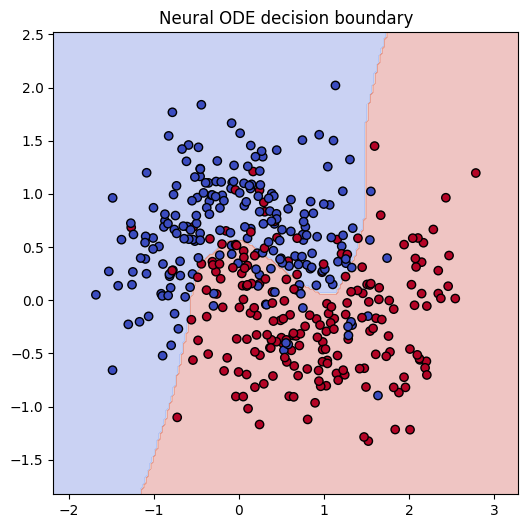

In [21]:
plot_decision_boundary(model, x_train.numpy(), y_train.numpy())